In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATASET_PATH = "/content/drive/MyDrive/Colab Notebooks/Animal Dataset"

classes = sorted(os.listdir(DATASET_PATH))
print("Classes:", classes)

Classes: ['cat', 'cow', 'dog', 'lamb', 'zebra']


In [3]:
from PIL import Image

clean_count = 0
corrupt_count = 0

for category in classes:
    folder_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            with Image.open(img_path) as img:
                img = img.convert("RGB")
                img.save(img_path, "JPEG")
                clean_count += 1

        except:
            os.remove(img_path)
            corrupt_count += 1

print("Cleaned images:", clean_count)
print("Removed corrupted images:", corrupt_count)

Cleaned images: 532
Removed corrupted images: 0


In [4]:
class_counts = {}
total_images = 0

for category in classes:
    folder_path = os.path.join(DATASET_PATH, category)

    num_images = len(os.listdir(folder_path))
    class_counts[category] = num_images
    total_images += num_images

print("Class-wise Image Count:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal Images:", total_images)

Class-wise Image Count:
cat: 111
cow: 101
dog: 105
lamb: 107
zebra: 108

Total Images: 532


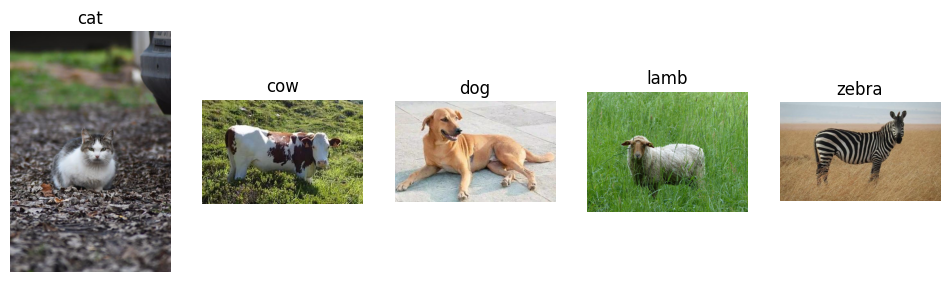

In [5]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(12,5))

for i, category in enumerate(classes):
    folder_path = os.path.join(DATASET_PATH, category)
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(category)
    plt.axis('off')

plt.show()

In [6]:
import cv2
import numpy as np
from skimage.feature import hog

IMG_SIZE = 64

data = []
labels = []

for label, category in enumerate(classes):
    folder_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(folder_path):
        try:
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(8, 8),
                cells_per_block=(2, 2),
                block_norm='L2-Hys'
            )

            data.append(features)
            labels.append(label)

        except:
            pass

data = np.array(data)
labels = np.array(labels)

print("Feature shape:", data.shape)

Feature shape: (532, 1764)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Train:", X_train.shape[0])
print("Test:", X_test.shape[0])

Train: 425
Test: 107


In [8]:
import numpy as np

print("Training Distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for i in range(len(unique)):
    print(f"{classes[unique[i]]}: {counts[i]}")

print("\nTesting Distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for i in range(len(unique)):
    print(f"{classes[unique[i]]}: {counts[i]}")

Training Distribution:
cat: 89
cow: 81
dog: 84
lamb: 85
zebra: 86

Testing Distribution:
cat: 22
cow: 20
dog: 21
lamb: 22
zebra: 22


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 5, 10],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}


In [11]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=classes))

Test Accuracy: 0.5981308411214953

Classification Report:

              precision    recall  f1-score   support

         cat       0.60      0.68      0.64        22
         cow       0.59      0.65      0.62        20
         dog       0.55      0.52      0.54        21
        lamb       0.57      0.55      0.56        22
       zebra       0.68      0.59      0.63        22

    accuracy                           0.60       107
   macro avg       0.60      0.60      0.60       107
weighted avg       0.60      0.60      0.60       107



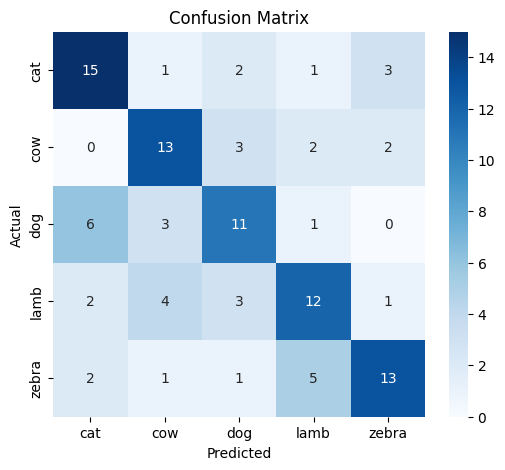

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

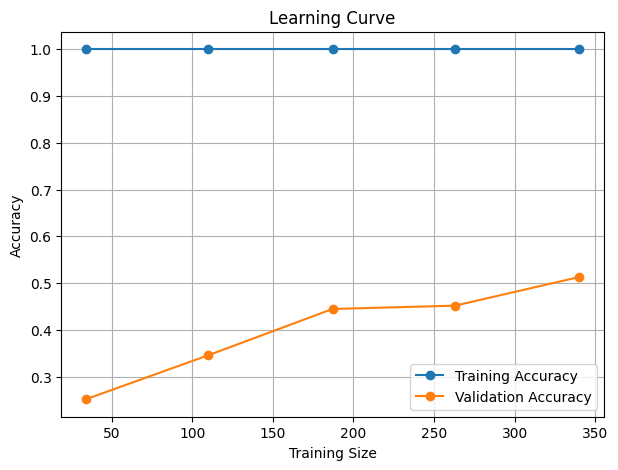

In [14]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    model, X_train, y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Accuracy')

plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()